In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [2]:
# loading the dataset
df=pd.read_csv("SupplyChainDataset.csv", encoding="latin1") 

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 53)

In [5]:
df_clean=df.copy()

In [6]:
df.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Type                                  0
Order Profit Per Order                0
Order Item Cardprod Id                0
Order Item Discount                   0
Order Item Discount Rate              0
Order Item Id                         0
Order Item Product Price              0
Order Item Profit Ratio               0
Order Item Quantity                   0
Sales                                 0
Order Item Total                      0
Order Region                          0
order date (DateOrders)               0
Order State                           0
Order Status                          0
Product Card Id                       0
Product Category Id                   0
Product Image                         0
Product Name                          0
Product Price                         0
Product Status                        0


In [7]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [8]:
columns_drop=['Benefit per order','Category Id','Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Latitude', 'Longitude',
        'Order City', 'Order Customer Id',
        'Order Id', 'Order Item Cardprod Id','Order Item Id','Order State',
        'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product Description', 'Product Image', 'Product Name','Product Status',
        'Order Item Discount','Order Item Product Price','Order Item Quantity',
        'Order Item Total',]

In [9]:
df_clean=df_clean.drop(columns=columns_drop)

In [10]:
df_clean.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Department Name', 'Market', 'Order Country',
       'order date (DateOrders)', 'Order Item Discount Rate',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Region', 'Order Status', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [11]:
df_clean.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Department Name,Market,Order Country,order date (DateOrders),Order Item Discount Rate,Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Indonesia,1/31/2018 22:56,0.04,0.29,327.75,91.250000,Southeast Asia,COMPLETE,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Fitness,Pacific Asia,India,1/13/2018 12:27,0.05,-0.80,327.75,-249.089996,South Asia,PENDING,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,Fitness,Pacific Asia,India,1/13/2018 12:06,0.06,-0.80,327.75,-247.779999,South Asia,CLOSED,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Australia,1/13/2018 11:45,0.07,0.08,327.75,22.860001,Oceania,COMPLETE,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Australia,1/13/2018 11:24,0.09,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,327.75,1/15/2018 11:24,Standard Class


In [12]:
# creating a new column to calculate no. of days the delivery was delayed by 
df_clean['Delay Days']=df_clean['Days for shipping (real)']-df_clean['Days for shipment (scheduled)']

In [13]:
# removing the cancelled orders
df_clean=df_clean[df_clean['Delivery Status']!='Shipping canceled']

In [14]:
# converting in standard datetime format
for i in['order date (DateOrders)','shipping date (DateOrders)']:
    df_clean[i]=pd.to_datetime(df_clean[i],errors='coerce',dayfirst=False)

In [15]:
# checking if the created KPI works perfectly
df_clean[['Days for shipping (real)','Days for shipment (scheduled)','Delivery Status',
          'Delay Days']].head(10)

,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Delay Days
0,3,4,Advance shipping,-1
1,5,4,Late delivery,1
2,4,4,Shipping on time,0
3,3,4,Advance shipping,-1
4,2,4,Advance shipping,-2
6,2,1,Late delivery,1
7,2,1,Late delivery,1
8,3,2,Late delivery,1
9,2,1,Late delivery,1
11,5,2,Late delivery,3


In [16]:
df_clean['Delivery Status'].value_counts()

Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

In [17]:
df_clean[df_clean['Delay Days']>0]['Delay Days'].mean()

np.float64(1.6181840225506936)

In [18]:
total_orders=df_clean['Shipping Mode'].value_counts()

In [19]:
late_orders=(df_clean[df_clean['Delivery Status'] == 'Late delivery'].groupby('Shipping Mode').size())

In [20]:
summary_table=pd.DataFrame({'Total Orders': total_orders,
              'Late Orders': late_orders})

In [21]:
summary_table['Late Delivery Rate (%)'] = round((summary_table['Late Orders'] / 
                                        summary_table['Total Orders']) * 100,1)

In [22]:
summary_table

,Total Orders,Late Orders,Late Delivery Rate (%)
Shipping Mode,,,
First Class,26513,26513,100.0
Same Day,9293,4454,47.9
Second Class,33806,26987,79.8
Standard Class,103153,41023,39.8


# First Class exhibits the highest late delivery rate (100%),indicating a severe operational issue or dataset-specific anomaly requiring investigation.Second Class also shows a high delay rate (79.8%), while Same Day performs significantly better with a delay rate below 50%.

In [23]:
summary_table.sort_values(by='Late Delivery Rate (%)', ascending=False)

,Total Orders,Late Orders,Late Delivery Rate (%)
Shipping Mode,,,
First Class,26513,26513,100.0
Second Class,33806,26987,79.8
Same Day,9293,4454,47.9
Standard Class,103153,41023,39.8


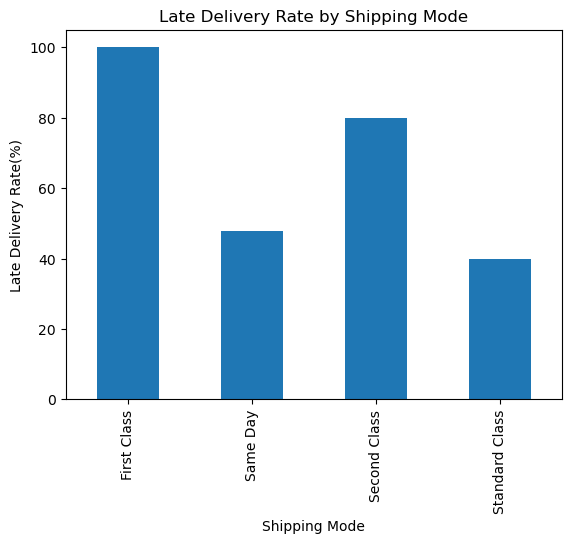

In [24]:
summary_table['Late Delivery Rate (%)'].plot(kind='bar')
plt.title('Late Delivery Rate by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate(%)')
plt.show()

# Why is First Class so often delayed ???

In [25]:
avg_late_delivery= (df_clean[df_clean['Delay Days']>0].groupby('Shipping Mode')['Delay Days'].mean())

In [26]:
summary_table['Avg Delay Day']=avg_late_delivery

In [27]:
summary_table

,Total Orders,Late Orders,Late Delivery Rate (%),Avg Delay Day
Shipping Mode,,,,
First Class,26513,26513,100.0,1.000000
Same Day,9293,4454,47.9,1.000000
Second Class,33806,26987,79.8,2.496795
Standard Class,103153,41023,39.8,1.506838


In [28]:
total_delay_days= (df_clean[df_clean['Delay Days']>0].groupby('Shipping Mode')['Delay Days'].sum())

In [29]:
summary_table['Total Delay Day']=total_delay_days

In [30]:
summary_table

,Total Orders,Late Orders,Late Delivery Rate (%),Avg Delay Day,Total Delay Day
Shipping Mode,,,,,
First Class,26513,26513,100.0,1.000000,26513
Same Day,9293,4454,47.9,1.000000,4454
Second Class,33806,26987,79.8,2.496795,67381
Standard Class,103153,41023,39.8,1.506838,61815


# Which regions have the highest late delivery rate for Second Class shipping?

In [31]:
total_orders_byRegion = (df_clean[df_clean['Shipping Mode'] == 'Second Class'].groupby('Order Region').size())

In [32]:
late_orders_byRegion = (df_clean[(df_clean['Shipping Mode'] == 'Second Class')&
              (df_clean['Delivery Status'] == 'Late delivery')].groupby('Order Region').size())

In [33]:
region_summary = pd.DataFrame({'Total Orders': total_orders_byRegion,'Late Orders': late_orders_byRegion})

In [34]:
region_summary['Late Delivery Rate (%)'] = (region_summary['Late Orders'] / region_summary['Total Orders']
                                             * 100)

In [35]:
region_summary

,Total Orders,Late Orders,Late Delivery Rate (%)
Order Region,,,
Canada,154,125,81.168831
Caribbean,1548,1277,82.493540
Central Africa,291,241,82.817869
Central America,5250,4111,78.304762
Central Asia,112,101,90.178571
East Africa,353,279,79.036827
East of USA,1222,956,78.232406
Eastern Asia,1341,1116,83.221477
Eastern Europe,755,578,76.556291


# Second Class shipping exhibits consistently high late delivery rates across nearly all regions. This suggests the issue is likely systemic rather than region-specific. The root cause may lie in the shipping process, carrier selection, scheduling policy, or operational workflow associated with Second Class shipments.

In [36]:
df_clean['Category Name'].value_counts()

Category Name
Cleats                  23514
Men's Footwear          21263
Women's Apparel         20116
Indoor/Outdoor Games    18470
Fishing                 16595
Water Sports            14880
Camping & Hiking        13157
Cardio Equipment        11948
Shop By Sport           10515
Electronics              3024
Accessories              1697
Golf Balls               1403
Girls' Apparel           1137
Golf Gloves              1029
Trade-In                  926
Video Games               804
Women's Clothing          631
Children's Clothing       622
Baseball & Softball       607
Hockey                    588
Cameras                   562
Toys                      507
Golf Shoes                502
Pet Supplies              472
Garden                    466
DVDs                      459
Crafts                    458
Golf Apparel              429
Computers                 425
Hunting & Shooting        424
Music                     417
Consumer Electronics      409
Boxing & MMA              

In [37]:
df_clean.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Department Name,Market,Order Country,...,Order Item Discount Rate,Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Price,shipping date (DateOrders),Shipping Mode,Delay Days
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Indonesia,...,0.04,0.29,327.75,91.250000,Southeast Asia,COMPLETE,327.75,2018-02-03 22:56:00,Standard Class,-1
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Fitness,Pacific Asia,India,...,0.05,-0.80,327.75,-249.089996,South Asia,PENDING,327.75,2018-01-18 12:27:00,Standard Class,1
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,Fitness,Pacific Asia,India,...,0.06,-0.80,327.75,-247.779999,South Asia,CLOSED,327.75,2018-01-17 12:06:00,Standard Class,0
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Australia,...,0.07,0.08,327.75,22.860001,Oceania,COMPLETE,327.75,2018-01-16 11:45:00,Standard Class,-1
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Australia,...,0.09,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,327.75,2018-01-15 11:24:00,Standard Class,-2


In [38]:
late_orders_byCategory=(df_clean[(df_clean['Shipping Mode']=='Second Class')&
              (df_clean['Delivery Status'] == 'Late delivery')].groupby('Category Name').size())

In [39]:
total_orders_byCategory=(df_clean[(df_clean['Shipping Mode']=='Second Class')].groupby('Category Name').size())

In [40]:
category_summary=pd.DataFrame({'Total Orders': total_orders_byCategory,
                               'Late Orders': late_orders_byCategory})

In [41]:
category_summary['Late Delivery Rate (%)'] = (category_summary['Late Orders'] / category_summary['Total Orders']
                                             * 100)

In [42]:
category_summary.sort_values('Late Delivery Rate (%)', ascending=False)

,Total Orders,Late Orders,Late Delivery Rate (%)
Category Name,,,
Basketball,10,10,100.000000
As Seen on TV!,14,13,92.857143
Fitness Accessories,56,50,89.285714
Golf Shoes,103,90,87.378641
Kids' Golf Clubs,58,50,86.206897
Strength Training,21,18,85.714286
Consumer Electronics,97,83,85.567010
Sporting Goods,65,55,84.615385
Garden,83,70,84.337349


In [43]:
category_summary[category_summary['Total Orders'] > 1000]

,Total Orders,Late Orders,Late Delivery Rate (%)
Category Name,,,
Camping & Hiking,2576,2004,77.795031
Cardio Equipment,2300,1825,79.347826
Cleats,4634,3712,80.103582
Fishing,3189,2562,80.338664
Indoor/Outdoor Games,3595,2870,79.833102
Men's Footwear,4222,3370,79.819991
Shop By Sport,2078,1669,80.317613
Water Sports,2980,2373,79.630872
Women's Apparel,3859,3050,79.036020


In [44]:
category_summary[category_summary['Total Orders'] > 1000].sort_values('Late Delivery Rate (%)', ascending=False)

,Total Orders,Late Orders,Late Delivery Rate (%)
Category Name,,,
Fishing,3189,2562,80.338664
Shop By Sport,2078,1669,80.317613
Cleats,4634,3712,80.103582
Indoor/Outdoor Games,3595,2870,79.833102
Men's Footwear,4222,3370,79.819991
Water Sports,2980,2373,79.630872
Cardio Equipment,2300,1825,79.347826
Women's Apparel,3859,3050,79.036020
Camping & Hiking,2576,2004,77.795031


# Checking by Order Status column

In [45]:
total_orders_byOrderStatus=(df_clean[(df_clean['Shipping Mode']=='Second Class')].groupby('Order Status').size())

In [46]:
late_orders_byOrderStatus=(df_clean[(df_clean['Shipping Mode']=='Second Class')&
              (df_clean['Delivery Status'] == 'Late delivery')].groupby('Order Status').size())

In [47]:
orderStatus_summary=pd.DataFrame({'Total Orders': total_orders_byOrderStatus,
                               'Late Orders': late_orders_byOrderStatus})

In [48]:
orderStatus_summary['Late Delivery Rate (%)'] = (orderStatus_summary['Late Orders'] / orderStatus_summary['Total Orders']
                                             * 100)

In [49]:
orderStatus_summary

,Total Orders,Late Orders,Late Delivery Rate (%)
Order Status,,,
CLOSED,3804,2995,78.732913
COMPLETE,11655,9301,79.802660
ON_HOLD,1815,1419,78.181818
PAYMENT_REVIEW,386,305,79.015544
PENDING,3886,3134,80.648482
PENDING_PAYMENT,8017,6470,80.703505
PROCESSING,4243,3363,79.259958


In [50]:
avg_profitBy_delivery=df_clean.groupby('Delivery Status')['Order Profit Per Order'].mean()

In [51]:
avg_profitBy_delivery

Delivery Status
Advance shipping    22.485701
Late delivery       21.621707
Shipping on time    22.709146
Name: Order Profit Per Order, dtype: float64

In [52]:
total_profit_generated=df_clean.groupby('Delivery Status')['Order Profit Per Order'].sum()

In [53]:
total_profit_generated

Delivery Status
Advance shipping    9.352253e+05
Late delivery       2.140052e+06
Shipping on time    7.311437e+05
Name: Order Profit Per Order, dtype: float64

In [54]:
df_clean['Delivery Status'].value_counts()

Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

In [55]:
df_clean.groupby('Shipping Mode')['Order Profit Per Order'].mean()

Shipping Mode
First Class       23.256392
Same Day          20.895527
Second Class      21.382638
Standard Class    22.033099
Name: Order Profit Per Order, dtype: float64

In [56]:
df_clean.groupby('Shipping Mode')['Order Profit Per Order'].sum()

Shipping Mode
First Class       6.165967e+05
Same Day          1.941821e+05
Second Class      7.228615e+05
Standard Class    2.272780e+06
Name: Order Profit Per Order, dtype: float64

In [57]:
df_clean['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    103153
Second Class       33806
First Class        26513
Same Day            9293
Name: count, dtype: int64

# Thus, Second Class shipping is the primary operational bottleneck. Nearly 80% of Second Class orders are delivered late, with an average delay of 2.5 days. Despite these delays, Second Class contributes approximately $0.72M in profit, making it a high-impact area for process improvement.

In [58]:
df_clean.groupby('Shipping Mode')[['Days for shipment (scheduled)',
                                   'Days for shipping (real)']].mean()

,Days for shipment (scheduled),Days for shipping (real)
Shipping Mode,,
First Class,1.0,2.000000
Same Day,0.0,0.479285
Second Class,2.0,3.993167
Standard Class,4.0,3.993699


In [59]:
df_clean[df_clean['Shipping Mode']=='Second Class']['Days for shipping (real)'].value_counts().sort_index()

Days for shipping (real)
2    6819
3    6759
4    6759
5    6772
6    6697
Name: count, dtype: int64

# Second Class shipping is the primary delivery bottleneck. Although customers are promised delivery within 2 days, actual delivery takes approximately 4 days on average. Delays are not caused by a small number of extreme cases; shipping times are distributed consistently between 2 and 6 days, indicating a systemic issue in the Second Class fulfillment process.

In [60]:
df_clean[df_clean['Shipping Mode']=='Second Class'].groupby('Market')['Delay Days'].mean()

Market
Africa          1.983740
Europe          2.007814
LATAM           1.988524
Pacific Asia    1.993486
USCA            1.977430
Name: Delay Days, dtype: float64

# Note: The Second Class delay problem is not region-specific and not market-specific. The average delay is approximately 2 days across all markets, indicating a company-wide process issue rather than a localized logistics problem.

# Time series analysis

In [61]:
df_clean['order date (DateOrders)'].head()

0   2018-01-31 22:56:00
1   2018-01-13 12:27:00
2   2018-01-13 12:06:00
3   2018-01-13 11:45:00
4   2018-01-13 11:24:00
Name: order date (DateOrders), dtype: datetime64[ns]

In [62]:
df_clean['order_month'] = df_clean['order date (DateOrders)'].dt.month
df_clean['order_day'] = df_clean['order date (DateOrders)'].dt.day_name()
df_clean['order_hour'] = df_clean['order date (DateOrders)'].dt.hour

In [63]:
total_orders_byMonth=(df_clean.groupby('order_month').size())
late_orders_byMonth=(df_clean[(df_clean['Delivery Status'] == 'Late delivery')].groupby('order_month').size())
month_summary=pd.DataFrame({'Total Orders': total_orders_byMonth,
                                  'Late Orders': late_orders_byMonth})
month_summary['Late Delivery Rate (%)'] = (month_summary['Late Orders'] / month_summary['Total Orders']
                                                 * 100)

In [64]:
month_summary

,Total Orders,Late Orders,Late Delivery Rate (%)
order_month,,,
1,17289,9827,56.839609
2,13845,7926,57.248104
3,15293,8796,57.516511
4,14775,8378,56.703892
5,15166,8745,57.661875
6,14482,8300,57.312526
7,15170,8607,56.736981
8,15305,8878,58.007187
9,14828,8565,57.762342


In [65]:
total_orders_byDay=(df_clean.groupby('order_day').size())
late_orders_byDay=(df_clean[(df_clean['Delivery Status'] == 'Late delivery')].groupby('order_day').size())
day_summary=pd.DataFrame({'Total Orders': total_orders_byDay,
                                  'Late Orders': late_orders_byDay})
day_summary['Late Delivery Rate (%)'] = (day_summary['Late Orders'] / day_summary['Total Orders']
                                                 * 100)

In [66]:
day_summary

,Total Orders,Late Orders,Late Delivery Rate (%)
order_day,,,
Friday,24875,14303,57.499497
Monday,24558,14196,57.806010
Saturday,24754,14089,56.916054
Sunday,24833,14300,57.584666
Thursday,24713,14165,57.318011
Tuesday,24585,13913,56.591418
Wednesday,24447,14011,57.311736


In [67]:
total_orders_byHour=(df_clean.groupby('order_hour').size())
late_orders_byHour=(df_clean[(df_clean['Delivery Status'] == 'Late delivery')].groupby('order_hour').size())
time_summary=pd.DataFrame({'Total Orders': total_orders_byHour,
                                  'Late Orders': late_orders_byHour})
time_summary['Late Delivery Rate (%)'] = (time_summary['Late Orders'] / time_summary['Total Orders']
                                                 * 100)

In [68]:
time_summary

,Total Orders,Late Orders,Late Delivery Rate (%)
order_hour,,,
0,7226,3907,54.068641
1,7275,4032,55.422680
2,7278,4017,55.193735
3,7098,3843,54.142012
4,7402,3973,53.674683
5,7243,4003,55.267154
6,7010,3704,52.838802
7,7227,3974,54.988239
8,7118,3782,53.132903


# Profitibility distribution analysis

In [69]:
profit_orders = (df_clean['Order Profit Per Order'] > 0).sum()

profit_orders

np.int64(139354)

In [70]:
loss_orders = (df_clean['Order Profit Per Order'] < 0).sum()

loss_orders

np.int64(32295)

In [71]:
breakeven_orders = (df_clean['Order Profit Per Order'] == 0).sum()

breakeven_orders

np.int64(1116)

In [72]:
profit_percentage=(profit_orders / len(df_clean)) * 100
loss_percentage=(loss_orders / len(df_clean)) * 100
breakeven_percentage=(breakeven_orders / len(df_clean)) * 100

In [73]:
profit_percentage

np.float64(80.661013515469)

In [74]:
loss_percentage

np.float64(18.693022313547303)

In [75]:
breakeven_percentage

np.float64(0.6459641709837062)

In [76]:
df_clean['Profit Status'] = 'Break-even'
df_clean.loc[df_clean['Order Profit Per Order'] > 0, 'Profit Status'] = 'Profit'
df_clean.loc[df_clean['Order Profit Per Order'] < 0, 'Profit Status'] = 'Loss' 

In [77]:
df_clean['Profit Status'].value_counts()

Profit Status
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

In [78]:
pd.crosstab(df_clean['Delivery Status'], df_clean['Profit Status'])

Profit Status,Break-even,Loss,Profit
Delivery Status,,,
Advance shipping,263,7772,33557
Late delivery,627,18553,79797
Shipping on time,226,5970,26000


In [79]:
pd.crosstab(df_clean['Delivery Status'],df_clean['Profit Status'],normalize='index') * 100

Profit Status,Break-even,Loss,Profit
Delivery Status,,,
Advance shipping,0.632333,18.686286,80.681381
Late delivery,0.633481,18.744759,80.621761
Shipping on time,0.701951,18.542676,80.755373


In [80]:
delay_distribution=(df_clean[df_clean['Delay Days'] > 0]['Delay Days'].value_counts().sort_index())

In [81]:
region_summary.sort_values('Late Delivery Rate (%)', ascending=False)

,Total Orders,Late Orders,Late Delivery Rate (%)
Order Region,,,
Central Asia,112,101,90.178571
Eastern Asia,1341,1116,83.221477
Central Africa,291,241,82.817869
South of USA,815,673,82.576687
Caribbean,1548,1277,82.493540
North Africa,590,483,81.864407
Western Europe,5206,4236,81.367653
Canada,154,125,81.168831
West of USA,1564,1254,80.179028


In [82]:
western_europe = df_clean[(df_clean['Order Region']=='Western Europe') &
                           (df_clean['Shipping Mode']=='Second Class')]

In [83]:
western_europe['Department Name'].value_counts()

Department Name
Fan Shop      1892
Apparel       1440
Golf           957
Footwear       435
Outdoors       255
Technology     123
Fitness         46
Book Shop       29
Discs Shop      29
Name: count, dtype: int64

In [84]:
total_orders_byDept = (western_europe.groupby('Department Name').size())
late_orders_byDept = (western_europe[western_europe['Delivery Status'] 
                       == 'Late delivery'].groupby('Department Name').size())
dept_summary = pd.DataFrame({'Total Orders': total_orders_byDept,'Late Orders': late_orders_byDept})
dept_summary['Late Delivery Rate (%)'] = (dept_summary['Late Orders']/ dept_summary['Total Orders']
                                            * 100)
dept_summary.sort_values('Late Delivery Rate (%)',ascending=False)

,Total Orders,Late Orders,Late Delivery Rate (%)
Department Name,,,
Fitness,46,41,89.130435
Outdoors,255,217,85.098039
Technology,123,103,83.739837
Golf,957,791,82.654127
Apparel,1440,1177,81.736111
Fan Shop,1892,1522,80.443975
Footwear,435,346,79.540230
Discs Shop,29,21,72.413793
Book Shop,29,18,62.068966


# Delay vs Discounts

In [85]:
avg_discount_by_delivery = (df_clean.groupby('Delivery Status')['Order Item Discount Rate'].mean())
avg_discount_by_delivery

Delivery Status
Advance shipping    0.101690
Late delivery       0.101694
Shipping on time    0.101329
Name: Order Item Discount Rate, dtype: float64

In [86]:
summary_table

,Total Orders,Late Orders,Late Delivery Rate (%),Avg Delay Day,Total Delay Day
Shipping Mode,,,,,
First Class,26513,26513,100.0,1.000000,26513
Same Day,9293,4454,47.9,1.000000,4454
Second Class,33806,26987,79.8,2.496795,67381
Standard Class,103153,41023,39.8,1.506838,61815


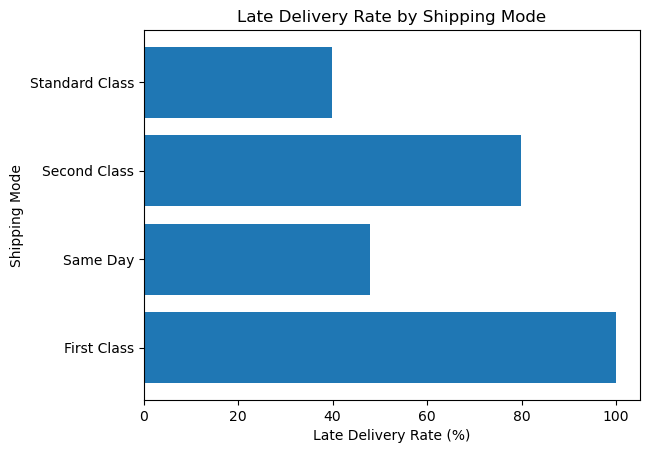

In [87]:
plt.barh(summary_table.index,summary_table['Late Delivery Rate (%)'])
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Shipping Mode')
plt.title('Late Delivery Rate by Shipping Mode')
plt.show()

Text(0.5, 1.0, 'Profitibility Distribution')

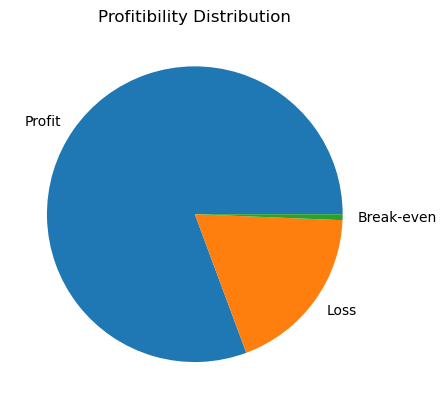

In [88]:
plt.pie( [profit_percentage,loss_percentage,breakeven_percentage], labels=["Profit","Loss","Break-even"] )
plt.title('Profitibility Distribution')

In [89]:
delay_distribution

Delay Days
1    57957
2    27551
3     6772
4     6697
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Delay Days')

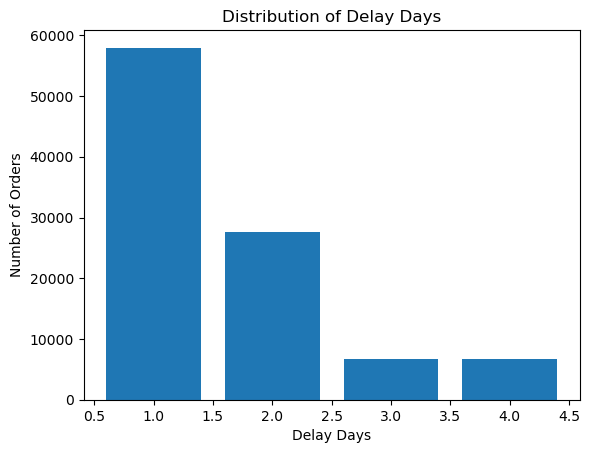

In [90]:
plt.bar(delay_distribution.index, delay_distribution.values)
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delay Days')

([<matplotlib.axis.XTick at 0x248055f9590>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

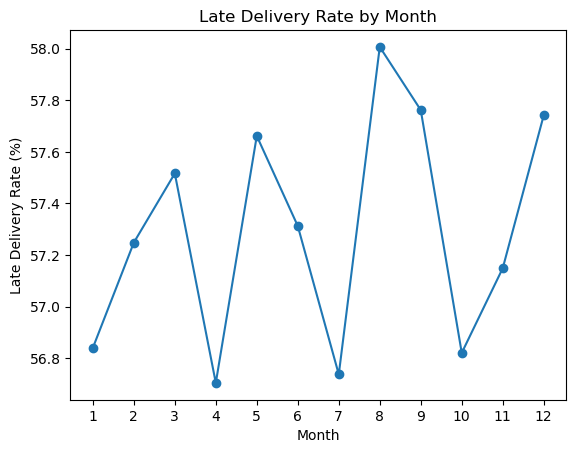

In [91]:
plt.plot(month_summary.index,month_summary['Late Delivery Rate (%)'],marker='o')
plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Month')
plt.xticks(range(1,13))

Text(0.5, 1.0, 'Late Delivery Rate by Day of Week')

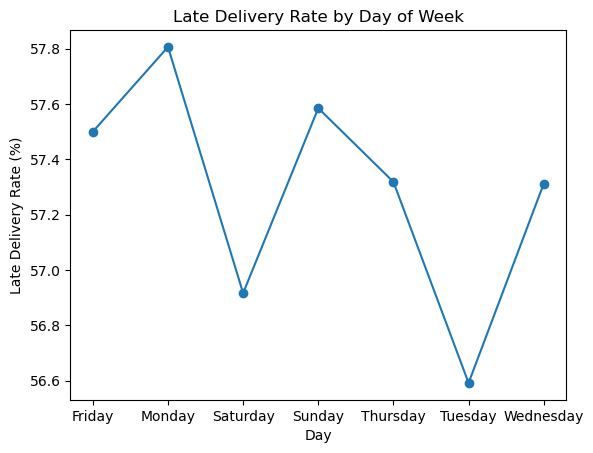

In [92]:
plt.plot(day_summary.index,day_summary['Late Delivery Rate (%)'],marker='o')
plt.xlabel('Day')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Day of Week')

([<matplotlib.axis.XTick at 0x24806679f90>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

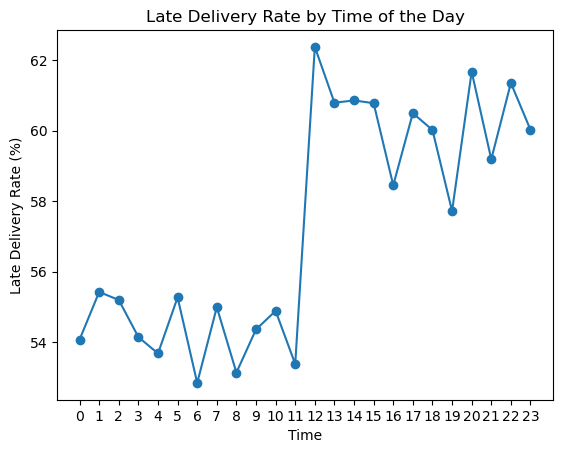

In [93]:
plt.plot(time_summary.index,time_summary['Late Delivery Rate (%)'],marker='o')
plt.xlabel('Time')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Time of the Day')
plt.xticks(range(0,24))

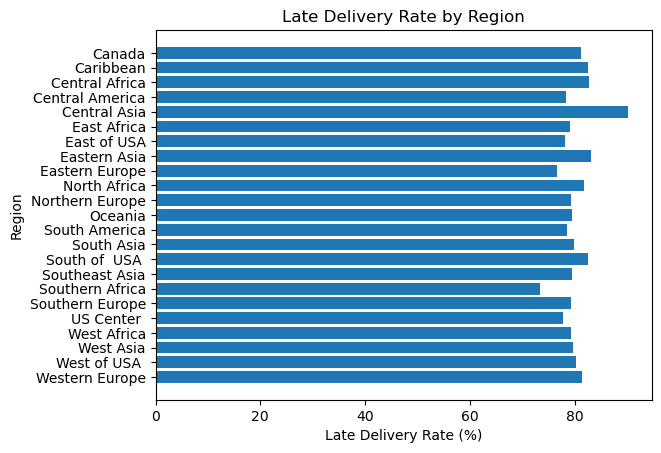

In [94]:
plt.barh(region_summary.index,region_summary['Late Delivery Rate (%)'])
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Region')
plt.title('Late Delivery Rate by Region')
plt.gca().invert_yaxis()

Text(0.5, 1.0, 'Late Delivery Rate by Department')

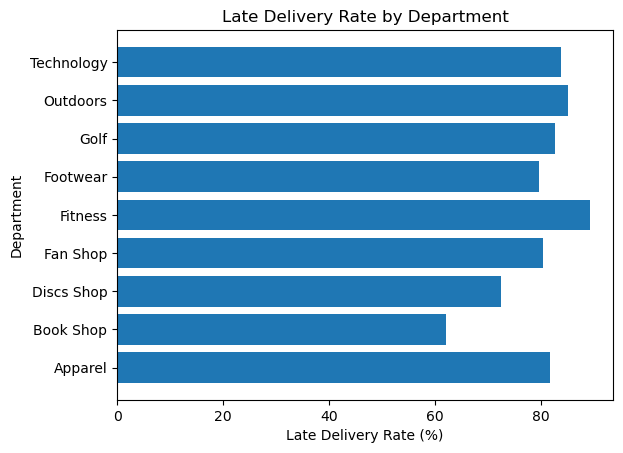

In [95]:
plt.barh(dept_summary.index,dept_summary['Late Delivery Rate (%)'])
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Department')
plt.title('Late Delivery Rate by Department')

Text(0.5, 1.0, 'Late Delivery Rate by Order Status')

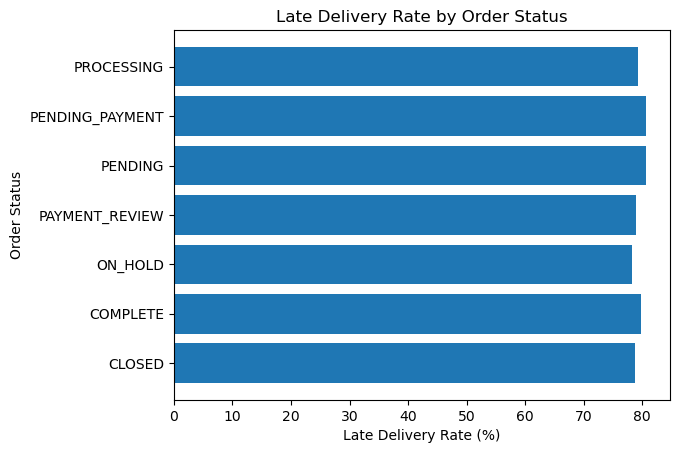

In [96]:
plt.barh(orderStatus_summary.index,orderStatus_summary['Late Delivery Rate (%)'])
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Order Status')
plt.title('Late Delivery Rate by Order Status')

Text(0.5, 1.0, 'Average Profit by Delivery Status')

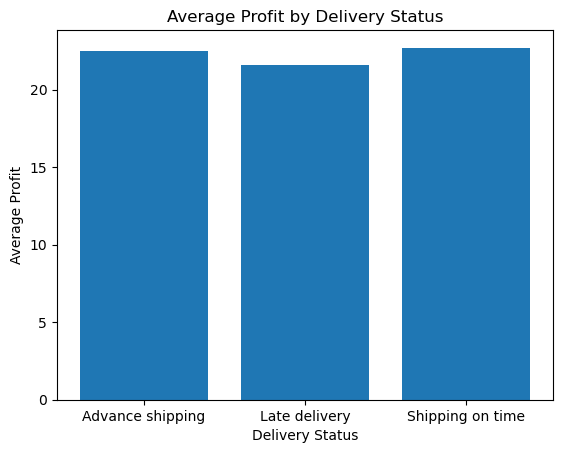

In [97]:
plt.bar(avg_profitBy_delivery.index,avg_profitBy_delivery.values)
plt.ylabel('Average Profit')
plt.xlabel('Delivery Status')
plt.title('Average Profit by Delivery Status')

Text(0.5, 1.0, 'Average Discount by Delivery Status')

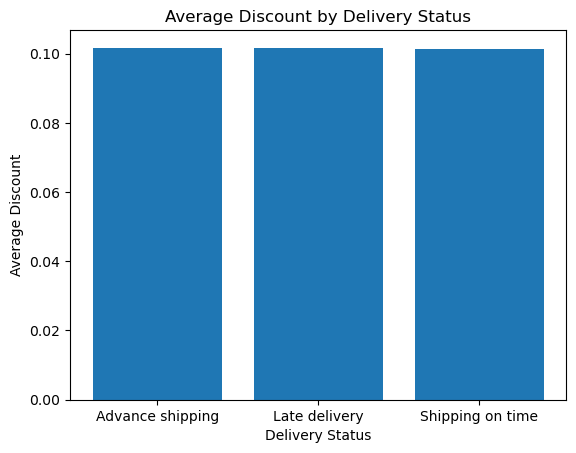

In [98]:
plt.bar(avg_discount_by_delivery.index,avg_discount_by_delivery.values)
plt.ylabel('Average Discount')
plt.xlabel('Delivery Status')
plt.title('Average Discount by Delivery Status')

In [99]:
heatmap_data = (pd.crosstab(df_clean['Delivery Status'],df_clean['Profit Status'],normalize='index')*100)

Text(0.5, 1.0, 'Delivery Status vs Profit Status (%)')

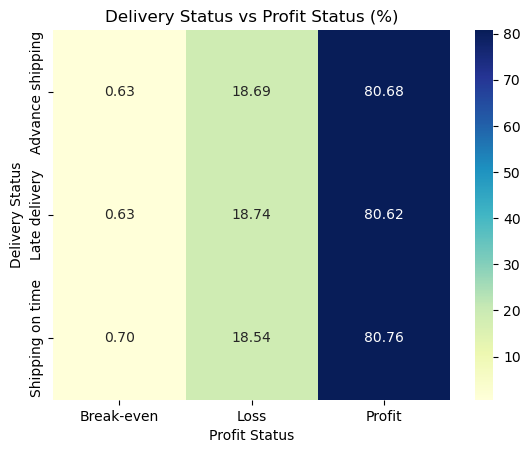

In [100]:
import seaborn as sns
sns.heatmap(heatmap_data,annot=True,fmt='.2f',cmap='YlGnBu')
plt.title('Delivery Status vs Profit Status (%)')

# PREDICTIVE ANALYSIS

In [101]:
df_ml=df_clean.copy()

In [102]:
df_ml.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Department Name,Market,Order Country,...,Order Region,Order Status,Product Price,shipping date (DateOrders),Shipping Mode,Delay Days,order_month,order_day,order_hour,Profit Status
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Indonesia,...,Southeast Asia,COMPLETE,327.75,2018-02-03 22:56:00,Standard Class,-1,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Fitness,Pacific Asia,India,...,South Asia,PENDING,327.75,2018-01-18 12:27:00,Standard Class,1,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,Fitness,Pacific Asia,India,...,South Asia,CLOSED,327.75,2018-01-17 12:06:00,Standard Class,0,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Australia,...,Oceania,COMPLETE,327.75,2018-01-16 11:45:00,Standard Class,-1,1,Saturday,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Australia,...,Oceania,PENDING_PAYMENT,327.75,2018-01-15 11:24:00,Standard Class,-2,1,Saturday,11,Profit


In [103]:
df_ml["Late"]=(df_ml["Delivery Status"]=="Late delivery").astype(int)
df_ml["Late"].value_counts()

Late
1    98977
0    73788
Name: count, dtype: int64

In [104]:
df_ml.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Department Name', 'Market', 'Order Country',
       'order date (DateOrders)', 'Order Item Discount Rate',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Region', 'Order Status', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Delay Days',
       'order_month', 'order_day', 'order_hour', 'Profit Status', 'Late'],
      dtype='object')

In [105]:
leakage_cols = [
    "Delivery Status",
    "Delay Days",
    "Days for shipping (real)",
    "shipping date (DateOrders)",
    "Profit Status","order date (DateOrders)",
    "Late_delivery_risk","Order Status",
    "Order Item Discount Rate","Order Item Profit Ratio",
    "Order Profit Per Order","Sales per customer"
]

df_ml = df_ml.drop(columns=leakage_cols)

In [106]:
df_ml.to_csv("SupplyChain_ML_Dataset.csv", index=False)

In [107]:
X = df_ml.drop("Late", axis=1)
y = df_ml["Late"]

categorical_cols = X.select_dtypes(include="object").columns

In [108]:
frequency_maps = {}

for col in categorical_cols:
    freq = X[col].value_counts(normalize=True)
    frequency_maps[col] = freq.to_dict()
    X[col] = X[col].map(freq)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [110]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [111]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Late
1    79182
0    59030
Name: count, dtype: int64
Late
0    79182
1    79182
Name: count, dtype: int64


In [112]:
rf_teacher = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_teacher.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [113]:
pred_teacher = rf_teacher.predict(X_test)

In [114]:
print("Accuracy:",accuracy_score(y_test,pred_teacher))
print(classification_report(y_test,pred_teacher))
print(confusion_matrix(y_test,pred_teacher))

Accuracy: 0.7633201169218302
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     14758
           1       0.82      0.75      0.78     19795

    accuracy                           0.76     34553
   macro avg       0.76      0.77      0.76     34553
weighted avg       0.77      0.76      0.76     34553

[[11461  3297]
 [ 4881 14914]]


In [115]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_teacher.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
12,order_hour,0.191391
9,Shipping Mode,0.151991
1,Days for shipment (scheduled),0.122563
10,order_month,0.088734
11,order_day,0.084000
5,Order Country,0.073133
6,Sales,0.069994
0,Type,0.053973
7,Order Region,0.053450
8,Product Price,0.035973


Text(0.5, 0, 'Feature Importance')

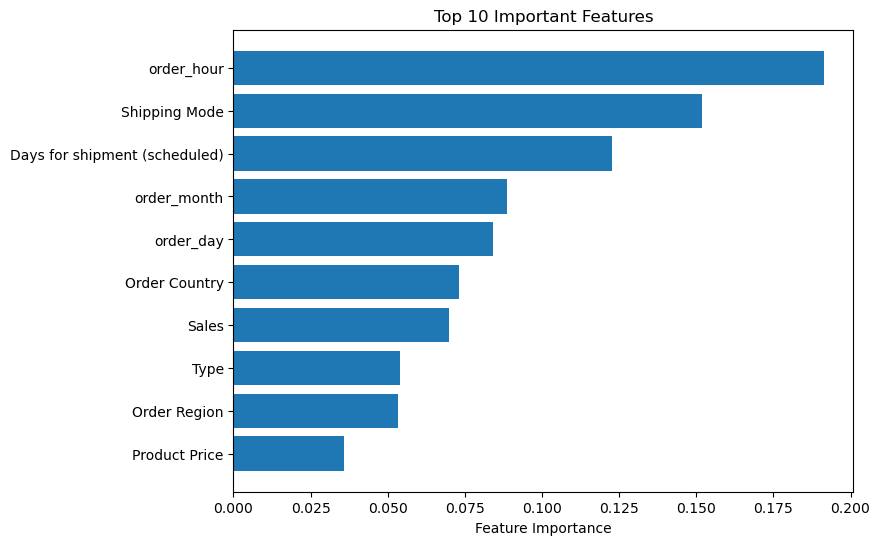

In [116]:
top = importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")


### Although the Decision Tree achieved a slightly higher accuracy (78.24% vs. 76.33%), I selected Random Forest because it is an ensemble model. It combines predictions from many decision trees, making it less prone to overfitting and more reliable on new, unseen data. The difference in accuracy is only about 2 percentage points, so I preferred the model that is generally more robust and stable.

In [117]:
joblib.dump(rf_teacher, "late_delivery_model.pkl")
joblib.dump(frequency_maps, "frequency_maps.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']